### Zipf's Law per variety

In [7]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
from datasets import load_dataset 
from collections import Counter

In [8]:
dataset = load_dataset('surrey-nlp/BESSTIE-CW-26')

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/711k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/70.6k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/415k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3747 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/313 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2183 [00:00<?, ? examples/s]

In [9]:
train_df = pd.DataFrame(dataset['train'])
val_df = pd.DataFrame(dataset['validation'])
test_df = pd.DataFrame(dataset['test'])

train_test_df = pd.concat([train_df, test_df], ignore_index = True)

uk_df = train_test_df[train_test_df['variety'] == 'en-UK']
au_df = train_test_df[train_test_df['variety'] == 'en-AU']
in_df = train_test_df[train_test_df['variety'] == 'en-IN']

print(f"{'-' * 5}Total samples {'-' * 5}")
print("UK: ", len(uk_df))
print("AU: ", len(au_df))
print("IN: ", len(in_df))

-----Total samples -----
UK:  1903
AU:  1812
IN:  2215


In [16]:
def get_word_frequencies(df):
    all_text = ' '.join(df['text'].tolist()).lower()
    words = all_text.split()
    freq = Counter(words)
    sorted_freq = sorted(freq.values(), reverse = True)
    return sorted_freq

In [17]:
uk_freq = get_word_frequencies(uk_df)
au_freq = get_word_frequencies(au_df)
in_freq = get_word_frequencies(in_df)

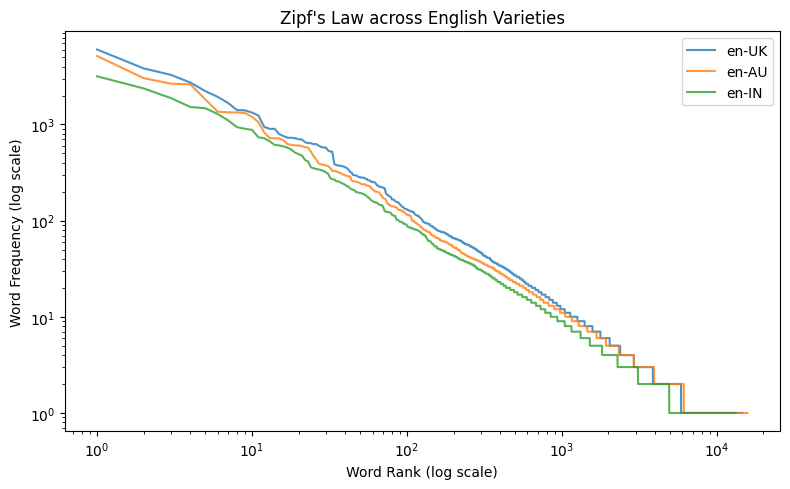

UK vocabulary size:  14564
AU vocabulary size:  15801
IN vocabulary size:  13242


In [18]:
# plot
fig, ax = plt.subplots(figsize=(8, 5))

for freq, label, color in zip(
    [uk_freq, au_freq, in_freq],
    ['en-UK', 'en-AU', 'en-IN'],
    ['#1f77b4', '#ff7f0e', '#2ca02c']
):
    ranks = range(1, len(freq) + 1)
    ax.loglog(ranks, freq, label=label, alpha=0.8)

ax.set_xlabel("Word Rank (log scale)")
ax.set_ylabel("Word Frequency (log scale)")
ax.set_title("Zipf's Law across English Varieties")
ax.legend()
plt.tight_layout()
plt.savefig('figures/zipfs_law.png', dpi=150)
plt.show()

print("UK vocabulary size: ", len(uk_freq))
print("AU vocabulary size: ", len(au_freq))
print("IN vocabulary size: ", len(in_freq))

In [19]:
def get_top_words(df, n=20):
    all_text = ' '.join(df['text'].tolist()).lower()
    words = all_text.split()
    freq = Counter(words)
    return freq.most_common(n)

print("Top 20 words - en-UK:")
print(get_top_words(uk_df))
print("Top 20 words - en-AU:")
print(get_top_words(au_df))
print("Top 20 words - en-IN:")
print(get_top_words(in_df))

Top 20 words - en-UK:
[('the', 6018), ('and', 3827), ('a', 3279), ('to', 2728), ('was', 2221), ('of', 1938), ('i', 1674), ('for', 1412), ('is', 1402), ('in', 1330), ('it', 1238), ('with', 943), ('but', 901), ('we', 900), ('on', 793), ('that', 756), ('not', 727), ('this', 727), ('as', 718), ('they', 702)]
Top 20 words - en-AU:
[('the', 5152), ('and', 3029), ('to', 2655), ('a', 2612), ('of', 1818), ('in', 1361), ('i', 1337), ('was', 1332), ('is', 1315), ('for', 1202), ('it', 1057), ('that', 825), ('but', 722), ('on', 717), ('with', 716), ('you', 683), ('are', 623), ('not', 613), ('be', 606), ('we', 605)]
Top 20 words - en-IN:
[('the', 3168), ('and', 2369), ('is', 1879), ('to', 1519), ('a', 1475), ('of', 1284), ('in', 1105), ('for', 938), ('i', 902), ('was', 879), ('it', 735), ('good', 719), ('are', 667), ('with', 613), ('but', 605), ('this', 591), ('not', 574), ('they', 545), ('you', 508), ('food', 492)]


In [23]:
# Took from AI - list of the most common stop words
stopwords = set([
    'the', 'and', 'a', 'to', 'of', 'in', 'i', 'is', 'was', 'for',
    'it', 'with', 'but', 'we', 'on', 'that', 'not', 'this', 'as',
    'they', 'you', 'are', 'be', 'at', 'an', 'my', 'me', 'so', 'or',
    'have', 'had', 'he', 'she', 'his', 'her', 'our', 'their', 'its',
    'from', 'by', 'were', 'been', 'there', 'which', 'who', 'all',
    'do', 'did', 'no', 'what', 'when', 'if', 'up', 'out', 'about',
    'just', 'get', 'got', 'can', 'will', 'would', 'could', 'very',
    'more', 'also', 'than', 'then', 'them', 'has', 'your', 'one',
    'time', 'here', 'like', 'even', 'how', 'some', 'am', 'us'
])

def get_top_content_words(df, n = 15):
    all_text = ' '.join(df['text'].tolist()).lower()
    
    words = []
    for w in all_text.split():
        if w not in stopwords and len(w) > 2:
            words.append(w)
    
    freq = Counter(words)
    return freq.most_common(n)

In [24]:
print("Top content words - en-UK:")
for word, count in get_top_content_words(uk_df):
    print(f"{word}: {count}")

print("Top content words - en-AU:")
for word, count in get_top_content_words(au_df):
    print(f"{word}: {count}")

print("Top content words - en-IN:")
for word, count in get_top_content_words(in_df):
    print(f"{word}: {count}")

Top content words - en-UK:
food: 601
n't: 582
good: 521
staff: 387
nice: 322
great: 315
it's: 295
really: 289
service: 279
only: 263
place: 262
people: 260
friendly: 184
well: 179
bit: 178
Top content words - en-AU:
it's: 328
good: 325
food: 306
n't: 244
people: 239
great: 212
only: 191
really: 183
don't: 181
staff: 169
service: 157
nice: 147
because: 147
place: 141
other: 140
Top content words - en-IN:
good: 719
food: 492
place: 350
taste: 235
it's: 209
good.: 197
chicken: 195
service: 190
people: 187
nice: 179
only: 172
best: 167
n't: 160
quality: 154
other: 145


## Error Linguistic Profiling

In [27]:
# Get all test predictions from RoBERTA
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

In [29]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


In [30]:
roberta_tokenizer = AutoTokenizer.from_pretrained('roberta-base')
roberta_model     = AutoModelForSequenceClassification.from_pretrained('models/roberta_sarcasm')
roberta_model     = roberta_model.to(device)
roberta_model.eval()

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

In [33]:
def get_predictions(texts, batch_size = 32):
    all_preds = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        encodings = roberta_tokenizer(
            batch_texts,
            truncation=True,
            padding=True,
            max_length=128,
            return_tensors='pt'
        )
        
        input_ids      = encodings['input_ids'].to(device)
        attention_mask = encodings['attention_mask'].to(device)

        with torch.no_grad():
            outputs = roberta_model(input_ids=input_ids, attention_mask=attention_mask)
            preds   = torch.argmax(outputs.logits, dim=1).cpu().numpy()

        all_preds.extend(preds)
    return all_preds

In [35]:
test_df = pd.DataFrame(dataset['test'])
test_df['Sarcasm'] = test_df['Sarcasm'].astype(int)
test_texts = test_df['text'].tolist()
test_preds = get_predictions(test_texts)
test_df['pred'] = test_preds

print("Predictions done!")
print("Total errors:", sum(test_df['Sarcasm'] != test_df['pred']))

Predictions done!
Total errors: 306


In [36]:
# Separate correct and incorrect predictions
errors   = test_df[test_df['Sarcasm'] != test_df['pred']]
correct  = test_df[test_df['Sarcasm'] == test_df['pred']]

In [40]:
print("Total errors: ", len(errors))
print("Total correct: ", len(correct))

Total errors:  306
Total correct:  1877


In [42]:
lengths = []

for text in errors['text']:
    lengths.append(len(text.split()))
errors['length'] = lengths

lengths_correct = []
for text in correct['text']:
    lengths_correct.append(len(text.split()))
correct['length'] = lengths_correct

In [43]:
print("Average sentence length:")
print("Errors: ", round(errors['length'].mean(), 2))
print("Correct: ", round(correct['length'].mean(), 2))

Average sentence length:
Errors:  39.84
Correct:  51.62


In [45]:
# Variety distribution of errors
print("Error distribution by variety:")
print(errors['variety'].value_counts())

print("Error rate per variety:")
for variety in ['en-UK', 'en-AU', 'en-IN']:
    total = len(test_df[test_df['variety'] == variety])
    n_errors = len(errors[errors['variety'] == variety])
    rate = round(n_errors / total * 100, 2)
    print(f"{variety}: {n_errors}/{total} ({rate}%)")

Error distribution by variety:
variety
en-AU    143
en-IN     96
en-UK     67
Name: count, dtype: int64
Error rate per variety:
en-UK: 67/700 (9.57%)
en-AU: 143/667 (21.44%)
en-IN: 96/816 (11.76%)


In [46]:
# Source distribution of errors
print("Error distribution by source:")
print(errors['source'].value_counts())

Error distribution by source:
source
Reddit    281
Google     25
Name: count, dtype: int64


### Calibration/ECE analysis

In [48]:
def get_confidence_scores(texts, batch_size=32):
    all_probs = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        encodings   = roberta_tokenizer(
            batch_texts,
            truncation=True,
            padding=True,
            max_length=128,
            return_tensors='pt'
        )
        input_ids = encodings['input_ids'].to(device)
        attention_mask = encodings['attention_mask'].to(device)

        with torch.no_grad():
            outputs = roberta_model(input_ids=input_ids, attention_mask=attention_mask)
            probs   = torch.softmax(outputs.logits, dim=1).cpu().numpy()
        all_probs.extend(probs)
    return all_probs

In [49]:
probs = get_confidence_scores(test_texts)
test_df['confidence'] = [max(p) for p in probs]

In [50]:
# ECE calculation
def compute_ece(y_true, y_pred, confidences, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1) # 3 buckets: [0-0.33], [0.33-0.66], [0.66-1.0]
    ece = 0.0
    total = len(y_true)

    for i in range(n_bins):
        mask = (confidences >= bins[i]) & (confidences < bins[i+1])
        if mask.sum() == 0:
            continue
        bin_acc = (y_true[mask] == y_pred[mask]).mean()
        bin_conf = confidences[mask].mean()
        ece += (mask.sum() / total) * abs(bin_acc - bin_conf)

    return round(ece, 4)

In [52]:
y_true = test_df['Sarcasm'].values
y_pred = test_df['pred'].values
confidences = test_df['confidence'].values

ece = compute_ece(y_true, y_pred, confidences)

print(f"Done!")

Done!


In [53]:
print(f"{'-'*5}Calibration Analysis{'-'*5}")
print(f"ECE (overall): {ece}")
print(f"Average confidence on correct predictions: {round(test_df[test_df['Sarcasm'] == test_df['pred']]['confidence'].mean(), 4)}")
print(f"Average confidence on errors: {round(test_df[test_df['Sarcasm'] != test_df['pred']]['confidence'].mean(), 4)}")

print("ECE per variety:")
for variety in ['en-UK', 'en-AU', 'en-IN']:
    mask = test_df['variety'] == variety
    ece_v = compute_ece(y_true[mask], y_pred[mask], confidences[mask])
    print(f"{variety}: {ece_v}")

-----Calibration Analysis-----
ECE (overall): 0.084
Average confidence on correct predictions: 0.9621999859809875
Average confidence on errors: 0.8306000232696533
ECE per variety:
en-UK: 0.0459
en-AU: 0.1421
en-IN: 0.0746


### Linguistic Feature Engineering

In [2]:
import re

In [4]:
def extract_pragmatic_features(text):
    features = {}

    # Exclamation marks 
    features['exclamation_count'] = text.count('!')

    # Question marks
    features['question_count'] = text.count('?')

    # The ratio of capitalisation 
    words = text.split()
    caps_words = []
    for w in words:
         if w.isupper() and len(w) > 1:
             caps_words.append(w)
    features['caps_ratio'] = len(caps_words) / max(len(words), 1)

    # Hyperbolic intensifiers - List took from AI 
    intensifiers = ['absolutely', 'totally', 'literally', 'honestly', 
                    'obviously', 'clearly', 'definitely', 'certainly',
                    'completely', 'utterly', 'perfectly', 'brilliant']
    text_lower = text.lower()
    count = 0
    for w in intensifiers:
        if w in text_lower:
            count += 1
    features['intensifier_count'] = count

    # Negation density
    negations = ["not", "never", "hardly", "barely", "neither", 
                 "nor", "nothing", "nobody", "nowhere", "n't"]
    count_negations = 0
    for w in negations:
        if w in text_lower:
            count += 1
    features['negation_count'] = count_negations

    # Ellipsis
    if '...' in text:
        features['ellipsis'] = 1
    else:
        features['ellipsis'] = 0

    # Sentence length 
    features['word_count'] = len(words)

    return features

In [10]:
# Application to full dataset
feature_rows = []
for _, row in test_df.iterrows():
    feats = extract_pragmatic_features(row['text'])
    feats['Sarcasm'] = row['Sarcasm']
    feats['variety'] = row['variety']
    feature_rows.append(feats)

features_df = pd.DataFrame(feature_rows)
print('Pragmatic features extracted')
print(features_df.head(3))

Pragmatic features extracted
   exclamation_count  question_count  caps_ratio  intensifier_count  \
0                  0               0         0.0                  0   
1                  0               0         0.0                  0   
2                  0               1         0.0                  0   

   negation_count  ellipsis  word_count  Sarcasm variety  
0               0         0          39      0.0   en-AU  
1               0         0          42      0.0   en-AU  
2               0         0          26      1.0   en-AU  


In [14]:
# Training classifiers on pragmatic features 

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report

# Fix sarcasm type
features_df['Sarcasm'] = features_df['Sarcasm'].astype(int)

# Preparing the features 
feature_cols = ['exclamation_count', 'question_count', 'caps_ratio',
                'intensifier_count', 'negation_count', 'ellipsis', 'word_count']

# Traning features 
train_feature_rows = []
for _, row in train_df.iterrows():
    feats = extract_pragmatic_features(row['text'])
    feats['Sarcasm'] = int(row['Sarcasm'])
    feats['variety'] = row['variety']
    train_feature_rows.append(feats)

train_features_df = pd.DataFrame(train_feature_rows)

X_train = train_features_df[feature_cols].values
y_train = train_features_df['Sarcasm'].values
X_test  = features_df[feature_cols].values
y_test  = features_df['Sarcasm'].values

# Training
clf = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
clf.fit(X_train, y_train)
preds = clf.predict(X_test)

print("--- Pragmatic features only -> LR ---")
print(classification_report(y_test, preds, target_names=['Not Sarcastic', 'Sarcastic']))

f1 = f1_score(y_test, preds, average='macro')
print(f"Macro F1: {round(f1, 4)}")

--- Pragmatic features only -> LR ---
               precision    recall  f1-score   support

Not Sarcastic       0.90      0.69      0.78      1878
    Sarcastic       0.22      0.55      0.32       305

     accuracy                           0.67      2183
    macro avg       0.56      0.62      0.55      2183
 weighted avg       0.81      0.67      0.72      2183

Macro F1: 0.5497


In [16]:
# Combining pragmatic features with TF-IDF to analyst thay they complement each other

from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(train_df['text'].tolist())
X_test_tfidf = tfidf.transform(test_df['text'].tolist())

# combine tfidf + pragmatic features -> learnt from AI -> Needed to combine these two features together
X_train_combined = sp.hstack([X_train_tfidf, sp.csr_matrix(X_train)])
X_test_combined = sp.hstack([X_test_tfidf, sp.csr_matrix(X_test)])

clf_combined = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
clf_combined.fit(X_train_combined, y_train)
preds_combined = clf_combined.predict(X_test_combined)

f1_combined = f1_score(y_test, preds_combined, average='macro')
print("---TF-IDF + Pragmatic Features -> LR---")
print(classification_report(y_test, preds_combined, target_names=['Not Sarcastic', 'Sarcastic']))
print(f"Macro F1: {round(f1_combined, 4)}")

---TF-IDF + Pragmatic Features -> LR---
               precision    recall  f1-score   support

Not Sarcastic       0.93      0.80      0.86      1878
    Sarcastic       0.33      0.60      0.42       305

     accuracy                           0.77      2183
    macro avg       0.63      0.70      0.64      2183
 weighted avg       0.84      0.77      0.80      2183

Macro F1: 0.6409
